# Applications of AI

## Homework 2 - AI in Social Media

### Marianna Kanellaki
### S-001081

- Collection of posts from Mastodon on AI topic
- Data cleaning and preparation
- Sentiment analysis using VADER
- Word Cloud visualization

### Post collection from Mastodon

In [53]:
access_token = '' # input your masstodon token

In [54]:
# Collecting 200 posts that have the hashtag AI

from mastodon import Mastodon
import pandas as pd

# mastodon auth
mastodon = Mastodon(
    access_token=access_token,
    api_base_url='https://mastodon.social' # Must match the server where you registered
)

hashtag = 'AI'
print(f"Fetching posts for #{hashtag}...")

# fetch first 40 posts (mastodon fetches 40 per call)
posts = mastodon.timeline_hashtag(hashtag, limit=40)
all_posts = posts

# fetch more posts (200 in total)
while len(all_posts) < 200 and posts:
    posts = mastodon.fetch_next(posts)
    if posts:
        all_posts.extend(posts)

print(f"Collected {len(all_posts)} posts.")

Fetching posts for #AI...
Collected 200 posts.


### Remove duplicates

In [55]:
print(f"Before removing duplicates: {len(all_posts)} posts")

unique_posts_dict = {post['id']: post for post in all_posts}
unique_posts = list(unique_posts_dict.values())

print(f"After removing duplicates: {len(unique_posts)} posts")

Before removing duplicates: 200 posts
After removing duplicates: 200 posts


In [56]:
# extract only the text content
raw_text_data = [post['content'] for post in unique_posts]
raw_text_data[0]

'<p>The Secret Weapon Against AI Dominance <a href="https://www.theatlantic.com/ideas/2026/04/creative-labor-ai-copyright/687000/?utm_source=feed" target="_blank" rel="nofollow noopener" translate="no"><span class="invisible">https://www.</span><span class="ellipsis">theatlantic.com/ideas/2026/04/</span><span class="invisible">creative-labor-ai-copyright/687000/?utm_source=feed</span></a> <a href="https://mastodon.social/tags/RegulateAI" class="mention hashtag" rel="tag">#<span>RegulateAI</span></a> <a href="https://mastodon.social/tags/Copyright" class="mention hashtag" rel="tag">#<span>Copyright</span></a> <a href="https://mastodon.social/tags/artists" class="mention hashtag" rel="tag">#<span>artists</span></a> <a href="https://mastodon.social/tags/authors" class="mention hashtag" rel="tag">#<span>authors</span></a> <a href="https://mastodon.social/tags/musicians" class="mention hashtag" rel="tag">#<span>musicians</span></a> <a href="https://mastodon.social/tags/creators" class="ment

I kept directly only the text, since it is the only data necessary for this analysis.

In [69]:
len(raw_text_data[0].split())

80

### Data Cleaning and Preparation

In [58]:
!pip install nltk

In [59]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/marianna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/marianna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to /home/marianna/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

##### Text Cleaning

Mastodon returns the results with their HTML tags, so the first step was to remove these. Then, all the text is cleaned. All words become lowercase, we remove all the urls, hashtags, emojis, punctuation, special characters, all numbers and all extra spaces.

In [78]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text) # remove html tags
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # remove URLs
    text = re.sub(r'\@\w+|\#', '', text)  # remove mentions and hashtags
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation, emojis & special characters
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

In [79]:
cleaned_texts = [clean_text(text) for text in raw_text_data]
cleaned_texts[0]

'the secret weapon against ai dominance theatlanticcomideas creativelaboraicopyrightutm_sourcefeed regulateai copyright artists authors musicians creators ai lawsuits copyrightinfringement humanauthor meta anthropic openai'

In [80]:
len(cleaned_texts[0].split())

21

##### Stopwords Removal

We remove stopwords from the text (such as articles, prepositions, pronouns), because they provide no or very little semantic value for sentiment analysis.

In [81]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = text.split()
    filtered_tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(filtered_tokens)

In [82]:
no_stopwords_texts = [remove_stopwords(text) for text in cleaned_texts]
no_stopwords_texts[0]

'secret weapon ai dominance theatlanticcomideas creativelaboraicopyrightutm_sourcefeed regulateai copyright artists authors musicians creators ai lawsuits copyrightinfringement humanauthor meta anthropic openai'

In [89]:
len(no_stopwords_texts[0].split())

19

##### Lemmatization

Lemmatization is used for text normalization, converting words into their base form. It makes the text more consistent thus improving model understanding of context and meaning.

In [84]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = text.split()    
    lemmatized_tokens = [lemmatizer.lemmatize(w) for w in tokens]    
    return ' '.join(lemmatized_tokens)

In [85]:

lemmatized_texts = [lemmatize_text(text) for text in no_stopwords_texts]
print(lemmatized_texts[0])

secret weapon ai dominance theatlanticcomideas creativelaboraicopyrightutm_sourcefeed regulateai copyright artist author musician creator ai lawsuit copyrightinfringement humanauthor meta anthropic openai


In [90]:
len(lemmatized_texts[0].split())

19

### Sentiment Analysis with VADER

For VADER, we are using a less clean version of the data, since it is designed specifically for social media text and relies on capitalization, punctuation, and emojis to understand sentiment intensity.

In [109]:
def lightly_clean_text(text):
    """ lighter data cleaning suitable for vader """

    text = str(text)
    text = re.sub(r'<.*?>', ' ', text) # remove html tags
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # remove URLs
    text = re.sub(r'\@\w+|\#', '', text)  # remove mentions and hashtags
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

In [110]:
cleaned_vader_texts = [lightly_clean_text(text) for text in raw_text_data]

Analyzer set up and analysis function

In [112]:
sia = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    if not text.strip():
        return 0.0

    scores = sia.polarity_scores(text) # gets sentiment scores (positive, negative, neutral, compound)
    return scores['compound'] # returns only the compound score (overall sentiment from -1 to +1)

In [113]:
scores = [analyze_sentiment(text) for text in cleaned_vader_texts]

Map score numbers to strings

In [114]:
def label_sentiment(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

sentiments = [label_sentiment(float(score)) for score in scores]

#### Results

In [119]:
total_score = sum(s for s in scores)
average_score = total_score / len(scores)

print(f"Overall Average Sentiment Score: {average_score:.3f} ({label_sentiment(average_score)})")

Overall Average Sentiment Score: 0.041 (neutral)


In [116]:
positive_count = sum(1 for s in sentiments if s == 'positive')
neutral_count = sum(1 for s in sentiments if s == 'neutral')
negative_count = sum(1 for s in sentiments if s == 'negative')

print(f"Positive: {positive_count} | Neutral: {neutral_count} | Negative: {negative_count}")

Positive: 70 | Neutral: 70 | Negative: 60


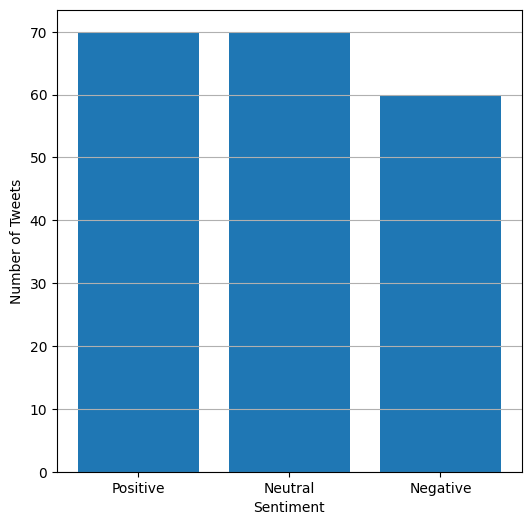

In [ ]:
import matplotlib.pyplot as plt

categories = ['Positive', 'Neutral', 'Negative']
counts = [positive_count, neutral_count, negative_count]

plt.figure(figsize=(6, 6))
plt.bar(categories, counts)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.grid(axis='y')
plt.show()

In [126]:
import statistics

# calculate metrics
count = len(scores)
mean = statistics.mean(scores)
std_dev = statistics.stdev(scores) if count > 1 else 0.0
minimum = min(scores)
maximum = max(scores)

q25, q50, q75 = statistics.quantiles(scores, n=4)

print("Sentiment Score Summary:\n")
print(f"count    {count}")
print(f"mean     {mean:.6f}")
print(f"std      {std_dev:.6f}")
print(f"min      {minimum:.6f}")
print(f"25%      {q25:.6f}")
print(f"50%      {q50:.6f}")
print(f"75%      {q75:.6f}")
print(f"max      {maximum:.6f}")


Sentiment Score Summary:

count    200
mean     0.041331
std      0.472049
min      -0.982300
25%      -0.196200
50%      0.000000
75%      0.435675
max      0.997300


Out of the 200 posts collected regarding the topic of AI, the sentiment distribution is very balanced. The dataset contains 70 positive posts (35%), 70 neutral posts (35%), and 60 negative posts (30%).

Statistically, the continuous VADER scores ranged from a minimum of -0.9823 to a maximum of 0.9973, with an overall mean sentiment score of 0.0413.

These data indicate a highly polarized and varied public discourse. There is no overwhelming consensus on Mastodon; users are expressing positive sentiments (up to 0.99) and negative sentiments (up to -0.98) at nearly equal rates. The big number of neutral posts probably represents users sharing news or code snippets without personal commentary.

### Word Cloud Visualization

In [127]:
!pip install wordcloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 6.8 MB/s  0:00:00


In [132]:
from wordcloud import WordCloud

all_words = " ".join(lemmatized_texts)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    collocations=False  # avoid combining word pairs
).generate(all_words)

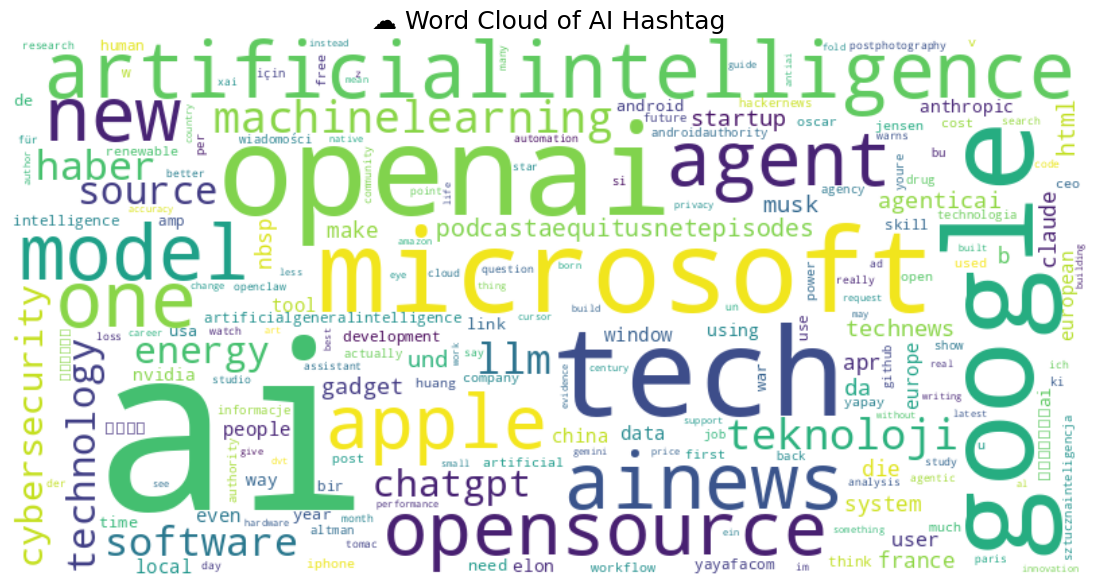

In [134]:
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("☁️ Word Cloud of AI Hashtag", fontsize=18)
plt.show()

The word cloud generated from the lemmatized and fully cleaned Mastodon data highlights several distinct themes in how users discuss AI.

The most prominent expressions in the dataset consist of neutral vocabulary, including company names, general tech terminology, countries, and news-related terminology. This suggests that a significant portion of the conversation is centered around the practical, business, and geographical development of AI, which aligns perfectly with the large volume of neutral sentiment scores observed in the previous step.

Additionally, with much less frequency, there is an emotional theme present, highlighted by words like "future", "life", and "loss". These expressions reflect the hopes and fears captured in the sentiment extremes (standard deviation 0.47). 

Finally, it is interesting to note the unexpected appearance of the word "drugs", which likely indicates many occuring conversations potentially regarding AI's application in pharmaceutical research.